# Вітаю на фінальному проєкті!
Протягом курсу ми навчились завантажувати дані в Python, трансформувати їх, чистити, агрегувати, знаходити з допомогою даних відповіді на наші питання, використовувати sql, а також Tableau!
Задача фінального проєкту - продемонструвати той рівень роботи з даними, на якому Ви є зараз, показати, що Ви вмі
те робити.

## Робота з Excel файлом
Цей ноутбук буде присвячений аналізу даних з файла `Grocery DataBase.xlsx`. Так, це Excel файл, і ми можемо дуже просто завантажувати дані з нього у Python. Покажу пару команд для роботи з Excel файлом.

Для початку встановимо бібліотеку, яка потрібна для роботи з Excel файлами з pandas. Можна встановити тут, або в терміналі, але якщо Ви встановлюєте в терміналі, то після того треба перезапустити ядро (Kernel) ноутбуку, аби бібліотека точно підтягнулась. Іноді підтягується і без того, але це на випадок, що робити, якщо компілятор каже, що її не бачить.

In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd

Ось так можемо переглянути, які є листки в Excel файлі:

In [ ]:
# замініть на шлях до файлу на своєму комп`ютері
path_to_file = '/content/drive/MyDrive/python_labs/final/Grocery Database.xlsx'

In [ ]:
xl = pd.ExcelFile(path_to_file)
xl.sheet_names

А так можемо зчитати конкретний листок:

In [ ]:
descr = xl.parse('Fact Summary')
print(descr)

Читати дані можна і з Pandas, але тут немає можливості переглянути наявні листки, а також довше відбувається читання даних.

In [ ]:
df = pd.read_excel(path_to_file)

In [ ]:
df.head()

В файлі ви знайдете опис колонок і значення.   

**Задача**: Уявіть, що Вам дали цей набір даних з питанням "Що корисного ми можемо з них взяти для розвитку нашого бізнесу?". То Вам необхідно розказати бізнесу історію про ці дані у форматі
1. питання, яке Вас цікавить щодо цих даних як співробітника цього бізнесу, який дуже вболіває за його успіх,
2. код для відповіді на це питання
3. висновки, які Ви зробили з огляду на результат виконання коду: які рішення ми можемо прийняти щодо подальших кроків в аналізі або які рекомендації Ви б дали бізнесу виходячи з результатів.

**Необхідно**

1. поставити до даних _мінімум_ 10 бізнес-питань, при цьому зробивши   
- початковий аналіз даних: їх розмір, структура, наявність пропущених значень та що з ними зробити, зміна типів даних там, де це доречно зробити (наприклад, якщо колонка завантажилась як тип string, а з опису видно, що там має бути float - варто змінити тип) - ця частина не входить у бізнес-питання, але є необхідною при аналізі даних.  
- _мінімум_ 1 зведеної таблиці (pivot) або її аналога
- _мінімум_ 5 візуалізацій, 3 з яких мають різний тип (наприклад, scatter plot, line plot, pair plot)
- _мінімум_ 1 використання тестування статистичних гіпотез. Наприклад, порівняти, чи стат значимо відрізняється певний цікавий бізнесу показник для чоловіків і жінок. Важливо, що найбільш доречно це буде, якщо той показник, який порівнюємо між групами, справді має доволі незначну різницю. Але потренуватись можна і при наявності значної. Питання тут насправді що таке "значна")) І воно залежить від співвідношення розміру середнього і стандартного відхилення.

    В даному мінімум-наборі немає вимоги на використання SQL. Але якщо Вам хочеться потренуватись, то Ви можете це зробити скориставшись pandasql.

    Питанням може бути як "Яка є кількість унікальних чеків в цьому наборі даних?" так і щось значно складніше. Якщо у Вас складне питання, і аби відповісти на нього Ви мали відповісти на 3 менших питання (зробити якісь трансформації над даними, подивитись щось), то це рахується як 3 питання з 10 необхідних у завданні. Звісно ж Ви можете зробити більше за встановлений мінімум - все буде перевірено :)

2. Розробити систему метрик для цього бізнесу (що нам цікаво вимірювати) і побудувати Tableau репорт відповідно до системи метрик. Опублікувати Tableau репорт на Tableau public і додати посилання на нього в ноутбуці з описом на кшталт "Візуалізацію у вигляді інтерактивного репорту даних можна знайти за посиланням".

По закінченню - завантажте ноутбук на git і додаємо посилання на ноутбук в здачу роботи в Kwiga.
До речі, з часом, Вам може захотітись доповнити цей ноутбук, коли арсенал Ваших навичок по роботі з даними розшириться. І це буде чудова ідея!

**Успіхів!**

#Фінальний проект

##**1. Завантаження та огляд даних**

In [1]:
!pip install openpyxl


Імпортуємо бібліотеки

In [52]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns


Завантажимо дані

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
path_to_file = '/content/drive/MyDrive/python_labs/final/Grocery Database.xlsx'


Листки в Excel файлі

In [6]:
xl_core = pd.ExcelFile(path_to_file, engine='openpyxl')

# Створення копії даних з вихідного файлу
sheets = {sheet_name: xl_core.parse(sheet_name) for sheet_name in xl_core.sheet_names}

# Збереження даних у новий файл (тимчасовий файл або в пам'яті)
with pd.ExcelWriter('temporary_copy.xlsx', engine='openpyxl') as writer:
    for sheet_name, df in sheets.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

# Зчитування нового файлу як копії
xl = pd.ExcelFile('temporary_copy.xlsx', engine='openpyxl')

print("Листки в Excel файлі:", xl.sheet_names)


Листки в Excel файлі: ['Grosto DB', 'Sheet2', 'Fact Summary']


Зчитування конкретного листка

In [7]:
df = xl.parse('Grosto DB')
print(df.head())


  Receipt Number       Date  Year  Month             Time  Mobile Number  \
0       GIJ00001 2016-01-02  2016      1  10:08:03.260000     9793548581   
1       GIJ00002 2016-01-02  2016      1  15:46:50.832000     9938441276   
2       GIJ00003 2016-01-02  2016      1  11:28:52.166000     9976742552   
3       GIJ00003 2016-01-02  2016      1  11:28:52.166000     9976742552   
4       GIJ00003 2016-01-02  2016      1  11:28:52.166000     9976742552   

  Membership ID  Loyalty Card Points  Age  Gender  ...  GST Gross Bill Amount  \
0     MIDID0001                    1   36    Male  ...  0.1          13.32408   
1     MIDID0002                    2   54    Male  ...  0.1          25.26480   
2     MIDID0003                    1   16  Female  ...  0.1          42.18786   
3     MIDID0003                    1   16  Female  ...  0.1          42.18786   
4     MIDID0003                    2   16  Female  ...  0.1          42.18786   

  Payment Mode                 Bank Name % Profit Margin

Цей датасет представляє собою записи покупок у продуктовому магазині, зокрема деталі про кожен чек, включаючи дату, час, номер чека, мобільний номер клієнта, ID, а також різні фінансові показники, такі як відсоток прибутковості, операційні витрати та собівартість продукту.

Дані містять корисну інформацію для аналізу купівельної поведінки, ефективності програм лояльності, демографічних характеристик клієнтів та фінансових показників магазину.

Розмір датасету

In [8]:
print(f"Розмір датасету: {df.shape}")


Розмір датасету: (50447, 32)


Огляд типів даних

In [9]:
print(df.dtypes)


Receipt Number                 object
Date                   datetime64[ns]
Year                            int64
Month                           int64
Time                           object
Mobile Number                   int64
Membership ID                  object
Loyalty Card Points             int64
Age                             int64
Gender                         object
City                           object
Country                        object
Category                       object
Sub_Category                   object
Items                          object
Brand                          object
Description                    object
Price                         float64
QTY                             int64
DISC                          float64
Amount                        float64
Net Bill Amount               float64
GST                           float64
Gross Bill Amount             float64
Payment Mode                   object
Bank Name                      object
% Profit Mar

Перевірка наявності пропущених значень

In [10]:
print(df.isnull().sum())


Receipt Number         0
Date                   0
Year                   0
Month                  0
Time                   0
Mobile Number          0
Membership ID          0
Loyalty Card Points    0
Age                    0
Gender                 0
City                   0
Country                0
Category               0
Sub_Category           0
Items                  0
Brand                  0
Description            0
Price                  0
QTY                    0
DISC                   0
Amount                 0
Net Bill Amount        0
GST                    0
Gross Bill Amount      0
Payment Mode           0
Bank Name              0
% Profit Margin        0
% Operating Cost       0
% Product Cost         0
Profit Margin          0
Operating Cost         0
Product Cost           0
dtype: int64


Отже, пропущених значень немає.

##**2. Попередня обробка даних**

*   Переведемо типи даних в більш доречні формати.
*   Видалимо або заповнимо пропущені значення, якщо вони є.

In [11]:
print("Назви стовпчиків:", df.columns)


Назви стовпчиків: Index(['Receipt Number', 'Date', 'Year', 'Month', 'Time', 'Mobile Number',
       'Membership ID', 'Loyalty Card Points', 'Age', 'Gender', 'City',
       'Country', 'Category', 'Sub_Category', 'Items', 'Brand ',
       'Description ', 'Price', 'QTY', 'DISC', 'Amount', 'Net Bill Amount',
       'GST', 'Gross Bill Amount', 'Payment Mode', 'Bank Name',
       '% Profit Margin', '% Operating Cost', '% Product Cost',
       'Profit Margin', 'Operating Cost', 'Product Cost'],
      dtype='object')


In [12]:
# Видаляємо зайві пробіли з назв стовпчиків
df.columns = df.columns.str.strip()


In [13]:
# Конвертуємо стовпчик 'Date' у формат дати
df['Date'] = pd.to_datetime(df['Date'])

# Переведемо деякі стовпчики у відповідні типи
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['QTY'] = df['QTY'].astype(int)

# Огляд оновлених типів даних
print(df.dtypes)

# Заповнення пропущених значень (наприклад, заповнення нулями або середніми значеннями)
df.fillna(0, inplace=True)


Receipt Number                 object
Date                   datetime64[ns]
Year                            int64
Month                           int64
Time                           object
Mobile Number                   int64
Membership ID                  object
Loyalty Card Points             int64
Age                             int64
Gender                         object
City                           object
Country                        object
Category                       object
Sub_Category                   object
Items                          object
Brand                          object
Description                    object
Price                         float64
QTY                             int64
DISC                          float64
Amount                        float64
Net Bill Amount               float64
GST                           float64
Gross Bill Amount             float64
Payment Mode                   object
Bank Name                      object
% Profit Mar

Тепер, можна переходити до детальнішого аналізу даних.

##**3. Бізнес-питання та аналіз даних**

###Питання 1: Яка є кількість унікальних чеків в цьому наборі даних?

In [14]:
unique_receipts = df['Receipt Number'].nunique()
print(f"Кількість унікальних чеків: {unique_receipts}")


Кількість унікальних чеків: 13048


**Висновок**

Кількість унікальних чеків у цьому наборі даних становить 13048. Це свідчить про велику кількість окремих транзакцій, які були зафіксовані протягом періоду збору даних. Аналізуючи ці транзакції, ми можемо отримати цінну інформацію про купівельну поведінку клієнтів, популярні товари та бренди, а також ефективність програм лояльності та маркетингових кампаній. Це дає нам змогу розробляти стратегії для покращення обслуговування клієнтів та збільшення продажів.

###Питання 2: Яка середня вартість одного чеку?

In [15]:
average_bill = df['Gross Bill Amount'].mean()
print(f"Середня вартість одного чеку: {average_bill}")


Середня вартість одного чеку: 72.3789157446429


**Висновок**

Середня вартість одного чеку становить 72.38. Це дає нам уявлення про середній розмір витрат клієнтів під час одного відвідування магазину. Висока середня вартість чека може свідчити про ефективні стратегії продажів, акції або програми лояльності, що спонукають клієнтів робити більші покупки. Навпаки, якщо ця вартість вважається низькою, це може бути сигналом для розробки нових маркетингових кампаній, програм лояльності або підвищення якості обслуговування для стимулювання збільшення витрат клієнтів.

###Питання 3: Який найпопулярніший спосіб оплати?

In [16]:
most_popular_payment_mode = df['Payment Mode'].mode()[0]
print(f"Найпопулярніший спосіб оплати: {most_popular_payment_mode}")


Найпопулярніший спосіб оплати: Card


**Висновок**

Найпопулярнішим способом оплати серед клієнтів є оплата карткою (Card).

Бізнес-пропозиції:

1. **Покращення інфраструктури для оплати карткою**: Забезпечити наявність достатньої кількості терміналів для безконтактних та карткових оплат, щоб уникнути черг та незручностей для клієнтів.

2. **Впровадження програм лояльності**: Пропонувати бонуси або знижки для клієнтів, які часто використовують карткові платежі, щоб заохотити їх до повторних покупок.

3. **Співпраця з банками**: Розглянути можливість співпраці з банками для надання спеціальних пропозицій або знижок для власників певних карток.

4. **Маркетинг**: Використовувати дані про популярність карткових оплат у маркетингових кампаніях, пропонуючи ексклюзивні акції для покупців, які обирають цей спосіб оплати.

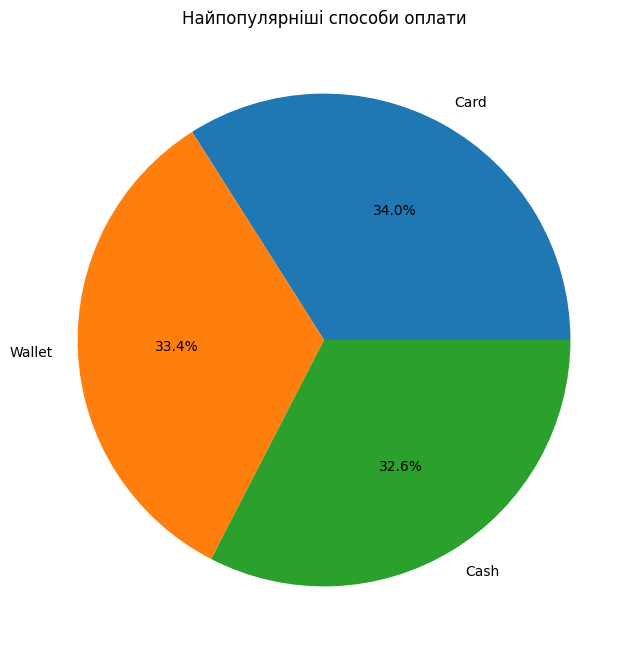

In [17]:
# Кругова діаграма найпопулярніших способів оплати
plt.figure(figsize=(8, 8))
df['Payment Mode'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Найпопулярніші способи оплати')
plt.ylabel('')
plt.show()


Згідно діаграми, всі 3 способи оплати становлять майже рівні частини, тому їх підтримці слід приділяти увагу.

###Питання 4: Яка кількість покупок за категоріями?

In [18]:
category_counts = df['Category'].value_counts()
print(category_counts)


Category
Bakery & Breakfast           6770
Frozen                       6393
Beauty                       5205
Fruit & Vegetable            4370
Pet Care                     3465
Dairy, Chilled & Eggs        3381
Choco, Snacks, Sweets        3019
Kitchen & Dining             2552
Rice & Cooking Essentials    2432
Beverages                    2208
Meat & Seafood               2149
Mother & Baby                2064
Household                    1881
Party Supplies               1836
Wines, Beers & Spirits       1714
Health                       1008
Name: count, dtype: int64


**Висновок**

Категорії з найбільшою кількістю покупок включають "Bakery & Breakfast" (6770 покупок), "Frozen" (6393 покупки) та "Beauty" (5205 покупок). Найменш популярні категорії — "Health" (1008 покупок) та "Wines, Beers & Spirits" (1714 покупок).

Бізнес-пропозиції:

1. **Підтримка популярних категорій**: Забезпечити наявність широкого асортименту товарів у найпопулярніших категоріях ("Bakery & Breakfast", "Frozen", "Beauty") та розширювати їх пропозицію для задоволення попиту.

2. **Промоції для менш популярних категорій**: Впровадити маркетингові кампанії та знижки для менш популярних категорій ("Health", "Wines, Beers & Spirits") для збільшення їх продажів.

3. **Аналіз купівельних тенденцій**: Дослідити причини популярності певних категорій та застосувати ці знання для оптимізації асортименту в інших категоріях.

4. **Крос-продажі**: Впровадити стратегії крос-продажів, пропонуючи знижки або спеціальні пропозиції для покупців, які купують товари з менш популярних категорій разом з популярними товарами.

5. **Інвентаризація та логістика**: Оптимізувати управління запасами для популярних категорій, щоб уникнути дефіциту товарів і забезпечити їх постійну наявність на полицях.

Графік розподілу кількості покупок за категоріями

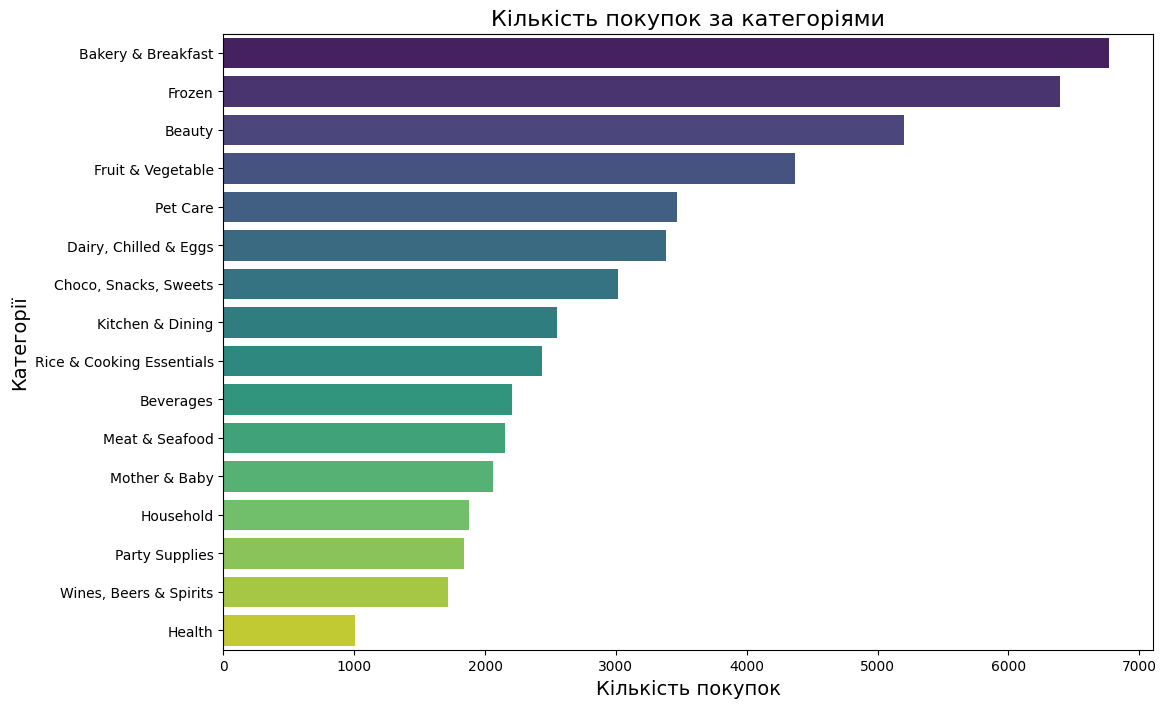

In [20]:
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# Налаштування розміру графіка
plt.figure(figsize=(12, 8))

# Побудова графіку
sns.barplot(x='Count', y='Category', data=category_counts, palette='viridis', hue='Category', dodge=False, legend=False)

# Додавання заголовку та міток осей
plt.title('Кількість покупок за категоріями', fontsize=16)
plt.xlabel('Кількість покупок', fontsize=14)
plt.ylabel('Категорії', fontsize=14)

# Відображення графіка
plt.show()


###Питання 5: Яка кількість покупок за містами?

In [21]:
city_counts = df['City'].value_counts()
print(city_counts)


City
Manila          12380
Bedok           12272
Kuala Lumpur    10763
Jakarta          9108
Woodlands        5924
Name: count, dtype: int64


**Висновок**

Найбільша кількість покупок зафіксована в таких містах:
- Manila: 12380 покупок
- Bedok: 12272 покупки
- Kuala Lumpur: 10763 покупки
- Jakarta: 9108 покупок
- Woodlands: 5924 покупки

Бізнес-пропозиції:

1. **Зосередження ресурсів на топових ринках**: Сконцентрувати маркетингові зусилля та ресурси в містах з найбільшою кількістю покупок (Manila, Bedok, Kuala Lumpur) для максимізації доходу.

2. **Розширення присутності**: Розглянути можливість відкриття нових магазинів або збільшення складів у містах з високою кількістю покупок для кращого обслуговування клієнтів.

3. **Цільові рекламні кампанії**: Запускати рекламні кампанії, спрямовані на мешканців міст з найвищими продажами, використовуючи місцеві ЗМІ та онлайн-платформи.

4. **Аналіз менш активних ринків**: Вивчити причини меншої кількості покупок в інших містах і розробити стратегії для збільшення продажів там, наприклад, через локальні акції або покращення асортименту.

5. **Персоналізація послуг**: Використовувати дані про покупки для створення персоналізованих пропозицій для клієнтів у різних містах, враховуючи місцеві вподобання та потреби.

Проведімо статистичний A/B тест на основі середньої вартості покупок між двома містами (Manila та Bedok)

In [27]:
# Фільтрація даних для двох міст
manila_purchases = df[df['City'] == 'Manila']['Gross Bill Amount']
bedok_purchases = df[df['City'] == 'Bedok']['Gross Bill Amount']

# Проведення t-тесту для порівняння середніх значень
t_stat, p_value = stats.ttest_ind(manila_purchases, bedok_purchases)

print(f"T-статистика: {t_stat}")
print(f"P-значення: {p_value}")

# Інтерпретація результатів
alpha = 0.05
if p_value < alpha:
    print("Існує статистично значуща різниця між середньою вартістю покупок у містах Manila та Bedok.")
else:
    print("Немає статистично значущої різниці між середньою вартістю покупок у містах Manila та Bedok.")


T-статистика: 3.0891702726841612
P-значення: 0.0020093960693858895
Існує статистично значуща різниця між середньою вартістю покупок у містах Manila та Bedok.


Оскільки p-значення (0.0020) менше рівня значущості (0.05), ми можемо зробити висновок, що існує статистично значуща різниця між середньою вартістю покупок у містах Manila та Bedok. Це означає, що середні значення вартості покупок в цих містах суттєво відрізняються, що підтверджується низьким p-значенням.

Бізнес-пропозиції:


1.   **Аналіз покупок:** Провести детальніший аналіз покупок у Manila та Bedok, щоб визначити причини відмінностей у середній вартості покупок.
2.   **Маркетингові стратегії:** Розробити та реалізувати різні маркетингові стратегії для кожного міста з урахуванням виявлених відмінностей.
Наприклад, підсилити маркетингові кампанії в Manila, де середня вартість покупок вища, щоб підтримувати та збільшувати цей показник.
3. **Ціноутворення:** Переглянути цінову політику в Bedok, щоб зрозуміти, чи є можливість підвищення середньої вартості покупок без втрати клієнтів.

4. **Асортимент продукції:** Звернути увагу на те, які продукти та категорії товарів популярніші в кожному місті, і адаптувати асортимент відповідно до місцевих потреб та вподобань.

5. **Лояльність клієнтів:** Розробити програми лояльності та спеціальні пропозиції для клієнтів в обох містах, з урахуванням різниць у їхніх купівельних звичках.

###Питання 6: Який середній вік покупців?

In [22]:
average_age = df['Age'].mean()
print(f"Середній вік покупців: {average_age}")


Середній вік покупців: 35.80177215691716


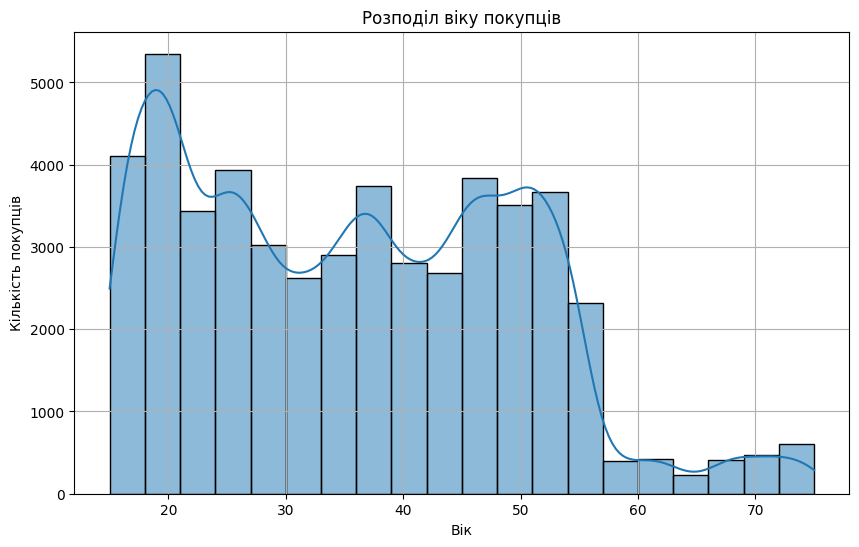

In [28]:
# Гістограма розподілу віку покупців
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Розподіл віку покупців')
plt.xlabel('Вік')
plt.ylabel('Кількість покупців')
plt.grid()
plt.show()


**Висновок**

На гістограмі розподілу віку покупців видно, що найбільша кількість покупців припадає на вік близько 20 років. Розподіл також показує значну кількість покупців у віці від 30 до 50 років. Середній вік покупців становить приблизно 36 років.

Бізнес-пропозиції:

1. **Маркетингові стратегії для молодих покупців**: Оскільки найбільша кількість покупців припадає на вік близько 20 років, слід розробити спеціальні маркетингові кампанії, спрямовані на молодь. Це можуть бути акції, знижки або спеціальні пропозиції для студентів та молодих професіоналів.

2. **Розширення асортименту для різних вікових груп**: Враховуючи значну кількість покупців у віковій групі 30-50 років, слід забезпечити широкий асортимент товарів, що відповідають потребам цієї категорії. Це можуть бути товари для дому, здорового харчування, сімейні товари та інші.

3. **Програми лояльності та винагороди**: Розробити програми лояльності, орієнтовані на різні вікові групи, зокрема на молодь та людей середнього віку. Це можуть бути накопичувальні бали, ексклюзивні пропозиції та інші вигоди.

4. **Цифровий маркетинг та соціальні мережі**: Активно використовувати цифрові канали для взаємодії з покупцями різних вікових груп. Соціальні мережі, мобільні додатки та електронні розсилки можуть бути ефективними для залучення як молодих покупців, так і людей середнього віку.

5. **Партнерство з брендами та компаніями**: Співпрацювати з брендами та компаніями, які орієнтовані на ці вікові групи, для спільних маркетингових акцій та спеціальних пропозицій, що можуть зацікавити покупців різного віку.

###Питання 7: Який середній чек для чоловіків та жінок?

In [29]:
average_bill_by_gender = df.groupby('Gender')['Gross Bill Amount'].mean()
print(average_bill_by_gender)


Gender
Female    72.807654
Male      70.299996
Name: Gross Bill Amount, dtype: float64


Скаттер-плот середнього чеку для чоловіків та жінок

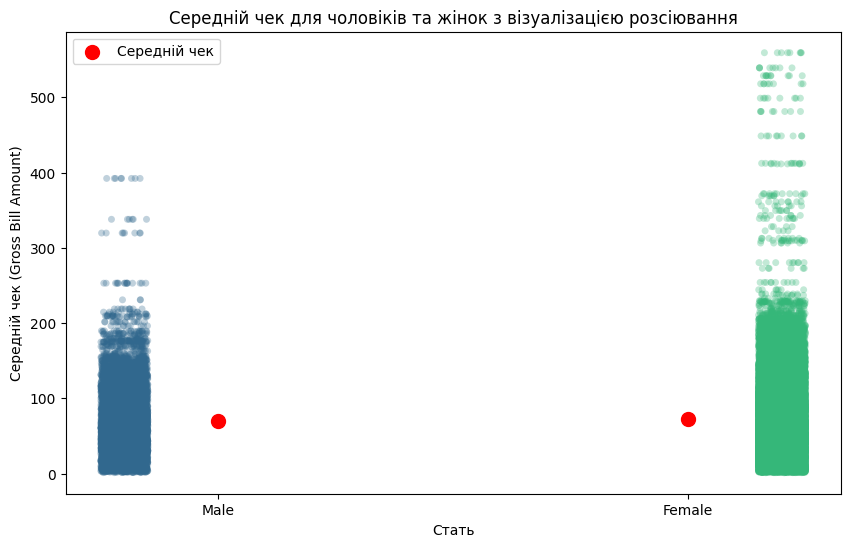

In [42]:
plt.figure(figsize=(10, 6))

# Додавання точок розсіювання для кожної транзакції
sns.stripplot(x='Gender', y='Gross Bill Amount', data=df, jitter=True, alpha=0.3, hue='Gender', dodge=True, palette='viridis', legend=False)

# Додавання середніх значень у вигляді великих точок
plt.scatter(['Female', 'Male'], average_bill_by_gender, color='red', s=100, label='Середній чек')

# Додавання заголовку та підписів осей
plt.title('Середній чек для чоловіків та жінок з візуалізацією розсіювання')
plt.xlabel('Стать')
plt.ylabel('Середній чек (Gross Bill Amount)')
plt.legend()

plt.show()


**Висновок**

За результатами аналізу середній чек складає:
- Для жінок: 72.81 одиниці валюти.
- Для чоловіків: 70.30 одиниць валюти.

Середній чек у жінок трохи вищий, ніж у чоловіків, але різниця невелика.

Бізнес пропозиції:
1. **Маркетингові стратегії**: Спрямовані маркетингові кампанії можуть залучати більше жіночої аудиторії, особливо якщо вони володіють вищим середнім чеком.
   
2. **Персоналізовані пропозиції**: Розробка персоналізованих пропозицій для кожної групи клієнтів може стимулювати збільшення середнього чеку у обох категорій клієнтів.

3. **Аналіз продуктової пропозиції**: Оцінка популярності товарів серед кожної групи клієнтів допоможе підвищити рентабельність за рахунок адаптації асортименту до специфіки попиту.

Ці кроки можуть допомогти оптимізувати прибутковість бізнесу за рахунок підвищення середнього чеку.

Також проведено t-тест для незалежних вибірок (`ttest_ind`) з бібліотеки `scipy.stats` для порівняння середніх значень сум рахунків між чоловіками та жінками:

- **Тестові статистики:** T-значення становить -4.32.
- **P-значення:** 1.56e-05 (дуже мале).



In [45]:
male_bills = df[df['Gender'] == 'Male']['Gross Bill Amount']
female_bills = df[df['Gender'] == 'Female']['Gross Bill Amount']

# Тестування гіпотез
t_stat, p_value = ttest_ind(male_bills, female_bills)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

if p_value < 0.05:
    print("Різниця в середньому розмірі чеку між чоловіками та жінками є статистично значущою.")
else:
    print("Різниця в середньому розмірі чеку між чоловіками та жінками не є статистично значущою.")


T-statistic: -4.319996690271764, P-value: 1.5632939825487073e-05
Різниця в середньому розмірі чеку між чоловіками та жінками є статистично значущою.


**Висновок**

Оскільки p-значення значно менше рівня значущості 0.05, ми відхиляємо нульову гіпотезу про те, що середні суми рахунків між чоловіками та жінками не відрізняються. Це свідчить про те, що різниця в середньому розмірі чеку між чоловіками та жінками є статистично значущою.

Бізнес пропозиції:

1. **Адаптація маркетингових кампаній:**
   - Слід зосередитися на жінках, які мають трохи вищий середній чек. Розробіть спеціальні акції або програми лояльності, орієнтовані на жінок.

2. **Персоналізовані пропозиції:**
   - Розгляньмо можливість впровадження персоналізованих пропозицій чи знижок для різних груп клієнтів, що можуть підвищити середній чек.

3. **Дослідження продуктів:**
   - Проведімо додаткове дослідження, щоб з'ясувати, які продукти чи послуги мають найбільший попит серед жінок і чоловіків, і оптимізуйте асортимент відповідно.

4. **Розширення досліджень:**
   - Проведімо також додаткові тести для вивчення інших факторів, які можуть впливати на середній чек, таких як вік, місце розташування або тип покупки.


###Питання 8: Яка кількість покупок за роками?

In [46]:
yearly_purchases = df['Year'].value_counts()
print(yearly_purchases)


Year
2019    15346
2018    13231
2017    11644
2016    10226
Name: count, dtype: int64


Лінійний графік кількості покупок за роками

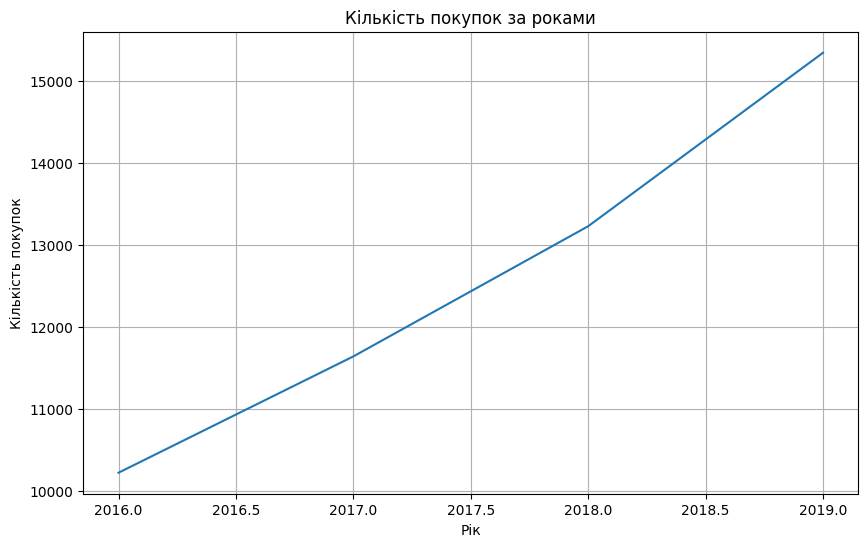

In [47]:
plt.figure(figsize=(10, 6))
yearly_purchases.sort_index().plot(kind='line')
plt.title('Кількість покупок за роками')
plt.xlabel('Рік')
plt.ylabel('Кількість покупок')
plt.grid()
plt.show()


**Висновок**

За останні чотири роки спостерігається позитивна динаміка у зростанні кількості покупок:

- **2019:** 15,346 покупок
- **2018:** 13,231 покупка
- **2017:** 11,644 покупок
- **2016:** 10,226 покупок

Це свідчить про тенденцію до зростання активності клієнтів.

Бізнес пропозиції:

1. **Розвиток інфраструктури:**
2. **Оптимізація логістики:**
3. **Маркетинг та просування:**
4. **Збільшення асортименту:**

Ці кроки дозволять оптимізувати діяльність підприємства та максимізувати прибутковість в умовах зростаючого попиту на продукцію або послуги.

###Питання 9: Який середній обсяг покупок (QTY) для кожної категорії?

In [54]:
average_qty_by_category = df.groupby('Category')['QTY'].mean().sort_values(ascending=False)
print(average_qty_by_category)



Category
Meat & Seafood               1.567706
Dairy, Chilled & Eggs        1.565217
Fruit & Vegetable            1.559497
Household                    1.559277
Bakery & Breakfast           1.554801
Beauty                       1.554083
Frozen                       1.549664
Wines, Beers & Spirits       1.549592
Rice & Cooking Essentials    1.548931
Kitchen & Dining             1.547806
Choco, Snacks, Sweets        1.541239
Party Supplies               1.538126
Mother & Baby                1.528101
Health                       1.524802
Pet Care                     1.521501
Beverages                    1.520380
Name: QTY, dtype: float64


**Висновок**

Середній обсяг покупок (QTY) для кожної категорії товарів відрізняється незначно, але все ж таки є відмінності:

- **Найвищий обсяг покупок**: Meat & Seafood (майже 1.57 одиниць) та Dairy, Chilled & Eggs (1.57 одиниць).
- **Найнижчий обсяг покупок**: Beverages (1.52 одиниць) та Pet Care (1.52 одиниць).

Це свідчить про те, що в кожній категорії є свої унікальні особливості споживання.

Бізнес пропозиції:

1. **Оптимізація асортименту**: Розгляньмо можливість розширення асортименту в категоріях з вищим середнім обсягом покупок для задоволення попиту.

2. **Крос-продажі і збільшення середнього чеку**: Слід розробити стратегії для стимулювання крос-продажів і підвищення середнього обсягу покупок на одного клієнта.

3. **Маркетингові акції**: Зосередьмо маркетингові кампанії на категоріях з меншим середнім обсягом покупок для збільшення їх привабливості серед клієнтів.

4. **Аналіз і прогнозування**: Використаємо аналітичні дані для прогнозування змін в споживчих звичках та адаптації бізнес-стратегій відповідно до цих змін.

Стовпчикова діаграма середнього обсягу покупок (QTY) для кожної категорії:

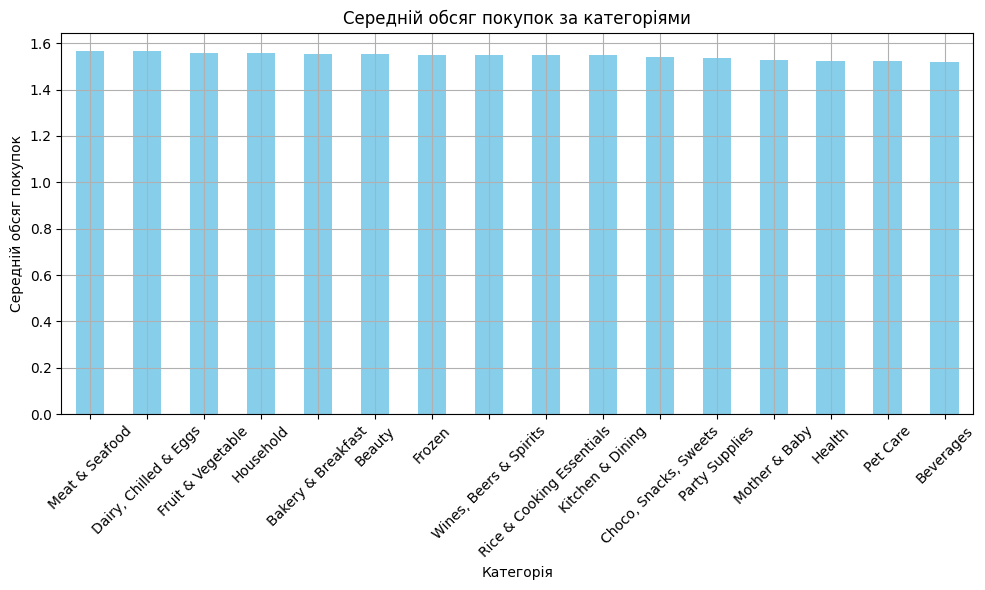

In [59]:
average_qty_by_category =  df.groupby('Category')['QTY'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
average_qty_by_category.plot(kind='bar', color='skyblue')
plt.title('Середній обсяг покупок за категоріями')
plt.xlabel('Категорія')
plt.ylabel('Середній обсяг покупок')

plt.xticks(rotation=45)

plt.tight_layout()
plt.grid()

plt.show()

###Питання 10: Які бренди мають найбільшу кількість продажів?

In [60]:
top_brands = df['Brand'].value_counts().head(10)
print(top_brands)


Brand
Biogreen         1163
BonJour          1070
RedMart           891
Sainbury          849
Ashai             813
Liang Teck        805
ThyGrace          792
Nature's Gift     763
Alpo              751
Anchor            730
Name: count, dtype: int64


**Висновок**

Найбільшу кількість продажів серед брендів мають такі компанії:

1. **Biogreen**: 1163 продажів
2. **BonJour**: 1070 продажів
3. **RedMart**: 891 продаж
4. **Sainbury**: 849 продажів
5. **Ashai**: 813 продажів

Ці бренди вирізняються значними обсягами продажів, що свідчить про їхню популярність серед споживачів.

Бізнес пропозиції:

1. **Стимулювання взаємодії з популярними брендами**: Можна розробити спеціальні промоакції та знижки для популярних брендів, що допоможе збільшити їхню впізнаваність та залучити нових клієнтів.

2. **Розширення асортименту**: Варто розглянути можливість розширення асортименту товарів цих брендів для задоволення попиту та збільшення обсягів продажів.

3. **Маркетинг і просування**: Інвестуймо в маркетингові кампанії для підвищення свідомості про ці бренди, що сприяє збільшенню їхньої популярності серед цільової аудиторії.

4. **Аналіз і прогнозування**: Сожна використовувати аналітичні дані для прогнозування та адаптації стратегій продажів залежно від змін у попиті на певні бренди.


##**4. Зведена таблиця**

In [61]:
pivot_table = df.pivot_table(
    values='Gross Bill Amount',
    index='City',
    columns='Category',
    aggfunc='mean'
).style.background_gradient(cmap='YlGnBu')

pivot_table


Category,Bakery & Breakfast,Beauty,Beverages,"Choco, Snacks, Sweets","Dairy, Chilled & Eggs",Frozen,Fruit & Vegetable,Health,Household,Kitchen & Dining,Meat & Seafood,Mother & Baby,Party Supplies,Pet Care,Rice & Cooking Essentials,"Wines, Beers & Spirits"
City,,,,,,,,,,,,,,,,
Bedok,66.998930,80.683962,70.942510,60.917538,60.078777,78.560602,76.196896,88.667625,74.981267,66.971156,81.113717,81.524802,64.836921,55.636323,63.851424,58.756352
Jakarta,70.441759,80.139044,78.715223,61.120449,63.190562,83.525380,81.253688,79.786528,81.309848,76.606685,85.026414,83.860778,65.692601,63.387447,70.422373,59.121840
Kuala Lumpur,69.175556,80.381060,78.751366,61.864176,59.170074,80.042119,70.788841,84.869080,78.999444,71.295001,82.453233,79.248780,55.593733,58.987541,70.328049,60.421136
Manila,70.304013,81.769044,75.281098,63.214170,63.979521,78.724480,73.088410,88.499348,79.480097,70.319745,82.218099,82.240679,63.665490,59.131598,68.887935,60.216601
Woodlands,72.017283,80.354881,78.009958,61.993534,65.721603,79.407390,77.321189,86.255649,77.446842,67.658569,92.237249,88.475742,66.869297,64.346077,72.738580,56.909021


Бізнес пропозиції:

1. **Персоналізовані пропозиції**: Персоналізовані маркетингові кампанії для кожного міста, враховуючи специфічні витрати в категоріях з найвищими середніми сумами рахунків.

2. **Оптимізація асортименту**: Аналіз попиту та підбір асортименту товарів в категоріях, що є популярними у конкретних містах, для збільшення задоволення клієнтів і зростання продажів.

3. **Розширення присутності**: Можливість розширення мережі магазинів у містах з високими середніми витратами на певні категорії товарів, що сприятиме збільшенню обсягів продажів.

4. **Постійний моніторинг та аналіз**: Постійний моніторинг та аналіз даних для вчасного виявлення нових тенденцій та можливостей для покращення ефективності бізнесу.

Ці кроки допоможуть оптимізувати стратегію продажів та максимізувати прибутковість від кожного міста, враховуючи його унікальні характеристики споживання.

##**5. Візуалізація метрик в Tableau**

Деякі додаткові метрики виконано в Tableau:

https://public.tableau.com/app/profile/olenka.olen/viz/final_dashboard_visualization/Dashboard1?publish=yes


Також додаю скрін дашборду та пояснення нижче:

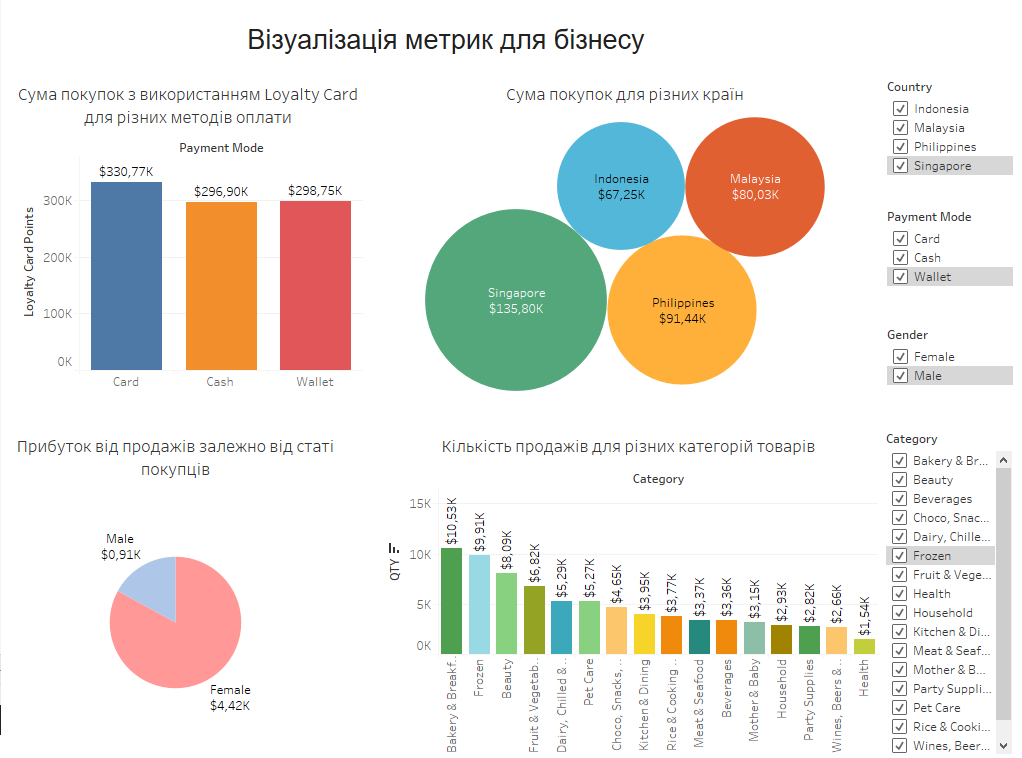

####**1. Сума покупок з використанням Loyalty Card для різних методів оплати**

- Цей графік показує суму покупок, здійснених з використанням Loyalty Card, розподілену за методами оплати: Card, Cash, Wallet.

- Найвища сума покупок з використанням Loyalty Card була здійснена за допомогою карток (Card), далі йдуть Wallet і Cash.

**Бізнес-пропозиції:**
- Сприяти використанню карток шляхом впровадження додаткових бонусів для користувачів карток.
- Розробити програми лояльності, які б стимулювали користувачів використовувати Wallet, оскільки він майже наздоганяє за популярністю картки.

#### **2. Сума покупок для різних країн**

- Графік представляє суму покупок, розподілену за країнами: Singapore, Philippines, Malaysia, Indonesia.

- Найбільшу суму покупок було зафіксовано в Singapore), тоді як в Indonesia найменшу.

**Бізнес-пропозиції:**
- Інвестувати більше в рекламні кампанії в Indonesia, щоб підвищити там рівень продажів.
- Аналізувати причини успішних продажів в Singapore і впроваджувати ці стратегії в інших країнах.

#### **3. Прибуток від продажів залежно від статі покупців**

- Цей графік показує розподіл прибутку від продажів між чоловіками та жінками.

- Жінки приносять значно більше прибутку ніж чоловіки.

**Бізнес-пропозиції:**
- Розробити маркетингові стратегії, спрямовані на жінок, враховуючи їх значний внесок у прибуток.
- Створювати спеціальні пропозиції для чоловіків, щоб залучити більше покупок з їхнього боку.

#### **4. Кількість продажів для різних категорій товарів**

- Графік представляє кількість продажів (QTY) для різних категорій товарів, таких як Bakery & Breakfast, Frozen, Beauty тощо.

- Найбільша кількість продажів припадає на категорію Bakery & Breakfast, за нею йдуть Frozen та Beauty.

**Бізнес-пропозиції:**
- Розширювати асортимент товарів у категорії Bakery & Breakfast, оскільки вона користується найбільшою популярністю.
- Аналізувати потреби та поведінку покупців у категоріях з меншою кількістю продажів, щоб підвищити їхню привабливість.



### Ось і все:) Дякую за корисний та цікавий курс!